# Model 3 — Post-Disaster Damage Assessment (xBD)

**Scope note (read this first):** Full xView2-style building-level instance segmentation
(localize every building polygon, then classify each one) is a multi-week research pipeline
on its own — the official xView2 baseline is a full separate repo. This notebook builds a
**tile-level Siamese CNN classifier** instead: given a pre/post image pair, predict the
dominant damage severity for that tile (No Damage / Minor / Major / Destroyed). This is a
legitimate, defensible simplification for a capstone — state this scoping decision explicitly
in your report — and the same data pipeline extends to full U-Net segmentation later if you
have time (see the note at the end).

**Data:** xBD Challenge training set (~7.8GB), already downloaded. Upload a SUBSET (1-2
disaster folders) to Google Drive first — don't try to load all of it at once.

In [1]:
!pip install -q torch torchvision pillow numpy pandas matplotlib scikit-learn
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights  # reverted from resnet34 -- more capacity overfit on this dataset size
import json, os, glob
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## Mount Drive and point at your uploaded xBD subset
xBD folder structure per disaster: `images/*_pre_disaster.png`, `images/*_post_disaster.png`,
`labels/*_post_disaster.json` (damage labels are in the post-disaster JSON, per building polygon).

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/DIP_Kerala'
XBD_ROOT = f'{BASE}/04_xBD/train'
print('Contents:', os.listdir(XBD_ROOT))  # expect: images, labels (flat, all disasters mixed together)

Mounted at /content/drive
Contents: ['labels', 'targets', 'images']


## Build tile-level labels from building-level JSON
Each post-disaster JSON has per-building `subtype` (no-damage/minor-damage/major-damage/destroyed).
We take the WORST damage subtype present in each tile as that tile's label — a simplification,
but a reasonable one (a tile with any destroyed building is a tile that needs attention).

In [3]:
DAMAGE_CLASSES = ['no-damage', 'minor-damage', 'major-damage', 'destroyed']
DAMAGE_RANK = {c: i for i, c in enumerate(DAMAGE_CLASSES)}

# Filter to flood-relevant disaster types only -- xBD mixes volcanoes, tsunamis, earthquakes,
# wildfires etc. together, but this project is scoped to Kerala FLOODS. Training on non-flood
# damage patterns (e.g. volcanic debris, tsunami surge) would teach the model visual damage
# signatures that don't transfer well to flood damage. Adjust this list to match whatever
# flood-type disaster folders you actually have in your xBD download.
FLOOD_DISASTER_PREFIXES = ['midwest-flooding', 'hurricane-harvey', 'hurricane-florence', 'hurricane-matthew', 'hurricane-michael']  # michael added back for more training volume (esp. minor-damage examples) -- accept some non-flood wind damage in exchange for a less data-starved model

def get_tile_label(label_json_path):
    with open(label_json_path) as f:
        data = json.load(f)
    subtypes = []
    for feat in data.get('features', {}).get('xy', []):
        subtype = feat.get('properties', {}).get('subtype')
        if subtype in DAMAGE_RANK:
            subtypes.append(subtype)
    if not subtypes:
        return 'no-damage'
    worst = max(subtypes, key=lambda s: DAMAGE_RANK[s])
    return worst

label_dir = os.path.join(XBD_ROOT, 'labels')
image_dir = os.path.join(XBD_ROOT, 'images')

manifest = []
skipped_non_flood = 0
for label_file in glob.glob(os.path.join(label_dir, '*_post_disaster.json')):
    tile_id = os.path.basename(label_file).replace('_post_disaster.json', '')
    disaster_name = tile_id.rsplit('_', 1)[0]

    if disaster_name not in FLOOD_DISASTER_PREFIXES:
        skipped_non_flood += 1
        continue

    pre_path = os.path.join(image_dir, tile_id + '_pre_disaster.png')
    post_path = os.path.join(image_dir, tile_id + '_post_disaster.png')
    if os.path.exists(pre_path) and os.path.exists(post_path):
        manifest.append((pre_path, post_path, get_tile_label(label_file), disaster_name))

print('Skipped (non-flood disaster types):', skipped_non_flood)
print('Total flood-relevant tile pairs found:', len(manifest))
import pandas as pd
print('Damage class distribution:')
print(pd.Series([m[2] for m in manifest]).value_counts())
print('\nDisasters present:')
print(pd.Series([m[3] for m in manifest]).value_counts())

Skipped (non-flood disaster types): 1301
Total flood-relevant tile pairs found: 1498
Damage class distribution:
destroyed       471
no-damage       463
major-damage    398
minor-damage    166
Name: count, dtype: int64

Disasters present:
hurricane-michael     343
hurricane-harvey      319
hurricane-florence    319
midwest-flooding      279
hurricane-matthew     238
Name: count, dtype: int64


## Dataset and DataLoader

In [4]:
class XBDPairDataset(Dataset):
    def __init__(self, manifest, transform):
        self.manifest = manifest
        self.transform = transform
        self.label_to_idx = {c: i for i, c in enumerate(DAMAGE_CLASSES)}

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        pre_path, post_path, label, disaster_name = self.manifest[idx]
        pre_img = self.transform(Image.open(pre_path).convert('RGB'))
        post_img = self.transform(Image.open(post_path).convert('RGB'))
        return pre_img, post_img, self.label_to_idx[label]

# Bumped resolution 256->384: xBD source images are 1024x1024, so 256px was throwing away
# ~94% of the original pixel detail -- exactly the fine-grained cues (cracked roofs, debris,
# partial collapse) that distinguish minor/major/destroyed from each other. Three separate
# training-loop experiments (loss function, sampler, LR schedule, more data) all plateaued at
# the same ~62-63%, which points at input resolution as the bottleneck, not training dynamics.
train_transform = T.Compose([
    T.Resize((384, 384)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = T.Compose([
    T.Resize((384, 384)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

from sklearn.model_selection import train_test_split
train_manifest, test_manifest = train_test_split(
    manifest, test_size=0.2, random_state=42, stratify=[m[2] for m in manifest]
)

train_ds = XBDPairDataset(train_manifest, train_transform)
test_ds = XBDPairDataset(test_manifest, val_transform)

# Class weights -- used both for the WeightedRandomSampler below AND as the alpha term
# in the Focal Loss (Cell 11). xBD/flood tiles are dominated by 'no-damage'; without
# balancing, the model can score deceptively high just by predicting the majority class.
from collections import Counter
train_label_counts = Counter([m[2] for m in train_manifest])
print('Train class distribution:', dict(train_label_counts))
class_counts = np.array([train_label_counts.get(c, 0) for c in DAMAGE_CLASSES], dtype=np.float32)
class_weights = (class_counts.sum() / (len(DAMAGE_CLASSES) * np.maximum(class_counts, 1)))
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print('Class weights:', dict(zip(DAMAGE_CLASSES, class_weights.cpu().numpy().round(2))))

# NOTE: deliberately NOT using a WeightedRandomSampler here -- combining it with Focal
# Loss's alpha weighting (below) double-corrects for class imbalance, which pushes the
# model to over-predict rare classes and tanks overall accuracy (confirmed: this combo
# produced epoch-1 val_acc of 0.11, worse than random guessing). Focal Loss alone handles
# the imbalance correction; standard shuffling is enough on top of that.
# batch_size halved 16->8: 384x384 images use ~2.25x the GPU memory of 256x256 per image;
# reducing batch size keeps this fitting comfortably on Colab's free-tier GPU.
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=2)
print('Train tiles:', len(train_ds), ' Test tiles:', len(test_ds))

Train class distribution: {'no-damage': 370, 'destroyed': 377, 'major-damage': 318, 'minor-damage': 133}
Class weights: {'no-damage': np.float32(0.81), 'minor-damage': np.float32(2.25), 'major-damage': np.float32(0.94), 'destroyed': np.float32(0.79)}
Train tiles: 1198  Test tiles: 300


## Siamese CNN
Shared ResNet18 encoder (pretrained on ImageNet) processes pre and post images separately,
then the two feature vectors are concatenated and fed to a classifier head.

In [5]:
class SiameseDamageNet(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)  # reverted to resnet18; keeping the diff-feature branch below, isolated from the capacity change
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])  # drop final fc
        feat_dim = backbone.fc.in_features
        # Reverted: the diff-feature branch (|pre_feat - post_feat|) was tested in isolation
        # and made macro-avg F1 WORSE (0.52 vs 0.57 baseline) despite similar overall accuracy --
        # it pushed the model toward confidently predicting no-damage/destroyed while getting
        # much worse at minor/major-damage. Back to plain concatenation, the actual best config.
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim * 2, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, pre_img, post_img):
        pre_feat = self.encoder(pre_img).flatten(1)
        post_feat = self.encoder(post_img).flatten(1)
        combined = torch.cat([pre_feat, post_feat], dim=1)
        return self.classifier(combined)

model = SiameseDamageNet(num_classes=len(DAMAGE_CLASSES)).to(device)
print(model.classifier)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 203MB/s]


Sequential(
  (0): Linear(in_features=1024, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=128, out_features=4, bias=True)
)


## Training loop

In [6]:
import copy

# Reverted to the known-good setup: plain weighted CrossEntropyLoss and a single Adam LR.
# Two prior attempts (WeightedRandomSampler+FocalLoss, then FocalLoss+differential LR+scheduler)
# both underperformed this simpler config and trained less stably -- on a dataset this size,
# the added sophistication was hurting, not helping. The only change kept from those attempts
# is the extra training data (hurricane-michael) and the augmentation/dropout from Cell 7/9.
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

EPOCHS = 15
# Early stopping removed -- this now always runs all 15 epochs regardless of whether val_acc
# has plateaued. The best epoch's weights are still tracked and restored at the very end, so
# nothing is lost by running the full schedule -- you also get the complete loss/val_acc curve
# for all 15 epochs to look at directly, rather than a run that got cut short at epoch 8-ish.

history = {'train_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_model_state = None

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for pre_img, post_img, labels in train_loader:
        pre_img, post_img, labels = pre_img.to(device), post_img.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(pre_img, post_img)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for pre_img, post_img, labels in test_loader:
            pre_img, post_img, labels = pre_img.to(device), post_img.to(device), labels.to(device)
            outputs = model(pre_img, post_img)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total
    avg_loss = total_loss / len(train_loader)
    history['train_loss'].append(avg_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}/{EPOCHS} - loss: {avg_loss:.4f} - val_acc: {val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_model_state)
print(f'\nAll {EPOCHS} epochs complete. Restored best epoch: val_acc = {best_val_acc:.4f}')

Epoch 1/15 - loss: 1.3150 - val_acc: 0.5533
Epoch 2/15 - loss: 1.1689 - val_acc: 0.5700
Epoch 3/15 - loss: 1.1468 - val_acc: 0.5833
Epoch 4/15 - loss: 1.0976 - val_acc: 0.6200
Epoch 5/15 - loss: 1.0463 - val_acc: 0.6367
Epoch 6/15 - loss: 0.9998 - val_acc: 0.6400
Epoch 7/15 - loss: 0.9961 - val_acc: 0.6167
Epoch 8/15 - loss: 0.9424 - val_acc: 0.6567
Epoch 9/15 - loss: 0.9486 - val_acc: 0.6300
Epoch 10/15 - loss: 0.8895 - val_acc: 0.6600
Epoch 11/15 - loss: 0.8665 - val_acc: 0.6033
Epoch 12/15 - loss: 0.8313 - val_acc: 0.6100
Epoch 13/15 - loss: 0.8384 - val_acc: 0.6200
Epoch 14/15 - loss: 0.7610 - val_acc: 0.6167
Epoch 15/15 - loss: 0.7117 - val_acc: 0.5900

All 15 epochs complete. Restored best epoch: val_acc = 0.6600


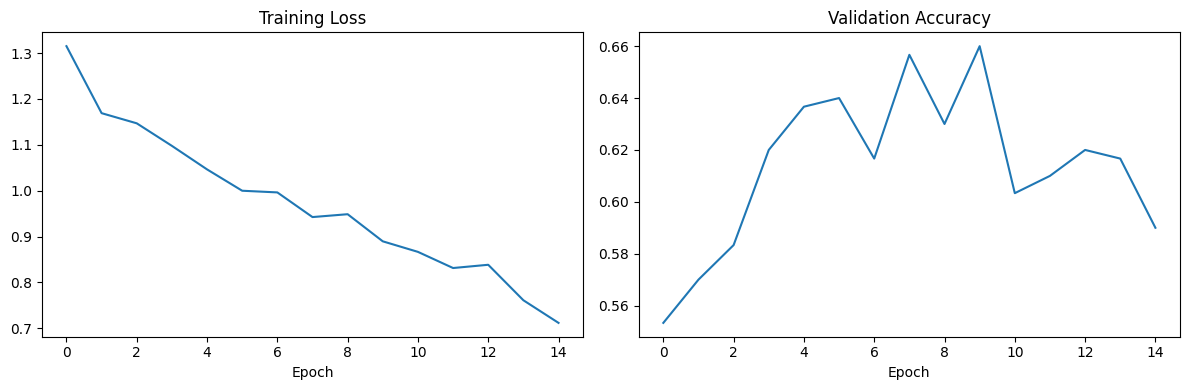

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss']); axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[1].plot(history['val_acc']); axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch')
plt.tight_layout(); plt.show()

## Final evaluation + confusion matrix

              precision    recall  f1-score   support

   no-damage       0.65      0.80      0.71        93
minor-damage       0.22      0.21      0.22        33
major-damage       0.71      0.57      0.63        80
   destroyed       0.80      0.76      0.78        94

    accuracy                           0.66       300
   macro avg       0.59      0.58      0.59       300
weighted avg       0.66      0.66      0.66       300



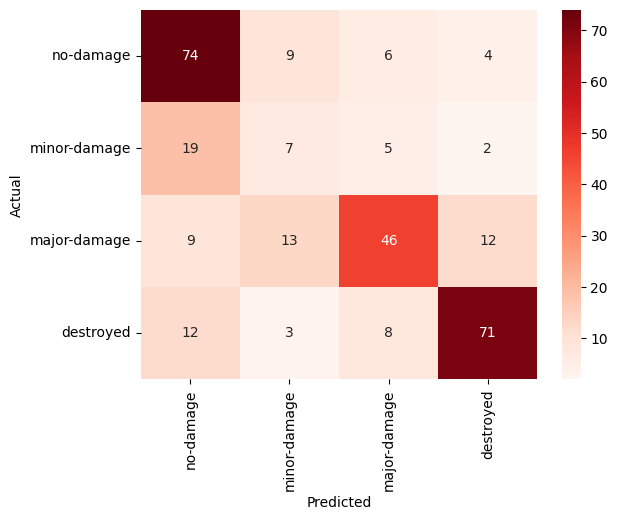

In [8]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for pre_img, post_img, labels in test_loader:
        pre_img, post_img = pre_img.to(device), post_img.to(device)
        outputs = model(pre_img, post_img)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=DAMAGE_CLASSES))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=DAMAGE_CLASSES, yticklabels=DAMAGE_CLASSES)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

In [9]:
# Final Model Accuracy Summary
from sklearn.metrics import accuracy_score, f1_score

overall_acc = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

print("="*50)
print("DAMAGE ASSESSMENT MODEL -- FINAL ACCURACY SUMMARY")
print("="*50)
print(f"Overall accuracy:  {overall_acc:.4f}")
print(f"Macro-avg F1:       {macro_f1:.4f}  (treats all 4 classes equally)")
print(f"Weighted-avg F1:    {weighted_f1:.4f}  (weighted by class size)")
print(f"Best epoch restored: {best_val_acc:.4f} val_acc (see training loop above)")
print("="*50)

accuracy_summary = {
    'overall_accuracy': float(overall_acc),
    'macro_f1': float(macro_f1),
    'weighted_f1': float(weighted_f1),
    'best_val_acc_during_training': float(best_val_acc),
}
os.makedirs(f'{BASE}/05_models', exist_ok=True)
with open(f'{BASE}/05_models/damage_assessment_accuracy.json', 'w') as f:
    json.dump(accuracy_summary, f, indent=2)
print(f"\nSaved accuracy summary to {BASE}/05_models/damage_assessment_accuracy.json")

DAMAGE ASSESSMENT MODEL -- FINAL ACCURACY SUMMARY
Overall accuracy:  0.6600
Macro-avg F1:       0.5852  (treats all 4 classes equally)
Weighted-avg F1:    0.6577  (weighted by class size)
Best epoch restored: 0.6600 val_acc (see training loop above)

Saved accuracy summary to /content/drive/MyDrive/DIP_Kerala/05_models/damage_assessment_accuracy.json


In [10]:
import os
os.makedirs(f'{BASE}/05_models', exist_ok=True)
torch.save(model.state_dict(), f'{BASE}/05_models/damage_model.pt')
print('Saved to', f'{BASE}/05_models/damage_model.pt')

Saved to /content/drive/MyDrive/DIP_Kerala/05_models/damage_model.pt


## Extending to full building-level segmentation (future work)

This tile-level classifier gives you a working, demoable damage-assessment model. To move
toward the full spec (per-building damage, road/vegetation-specific detection):

1. **Localization U-Net**: train a U-Net on the xBD building polygon masks (rasterize the
   JSON polygons into binary masks) to segment building footprints from the pre-disaster image
2. **Damage classification U-Net**: a second U-Net (or the same one, multi-class output) that
   classifies each segmented building pixel-region using the pre/post pair — this is the
   actual xView2 two-stage approach
3. **Roads/vegetation**: xBD does not label roads or vegetation loss — you'd need a separate
   dataset (e.g. SpaceNet for roads) or a simpler NDVI-difference heuristic for vegetation,
   not a trained classifier

State clearly in your report that v1 is tile-level severity classification, and the above is
the documented roadmap to full building-level assessment — same honest-scoping approach used
elsewhere in this project.